# Fourier Transform Denoising Project v2 (Interactive)

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display, clear_output
import ipywidgets as widgets
from utils.fft_filters import apply_low_pass_fft
print('imports ok')

imports ok


(np.float64(-0.5), np.float64(2046.5), np.float64(1364.5), np.float64(-0.5))

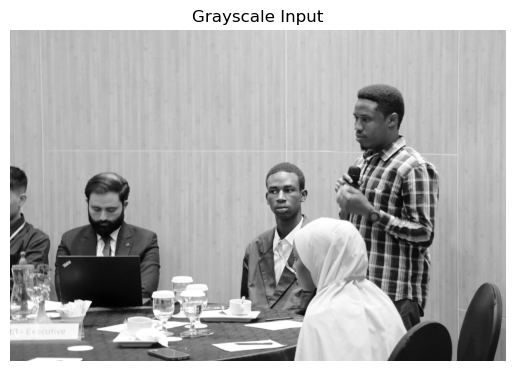

In [2]:
image_path = '_MG_6410.JPG'
img_bgr = cv2.imread(image_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale Input'); plt.axis('off')

(np.float64(-0.5), np.float64(2046.5), np.float64(1364.5), np.float64(-0.5))

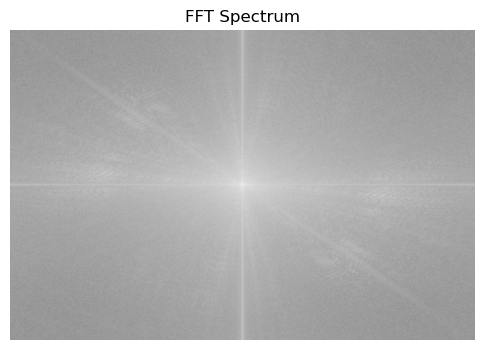

In [3]:
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)
magnitude = np.log1p(np.abs(fshift))
plt.figure(figsize=(6,6))
plt.imshow(magnitude, cmap='gray', norm=LogNorm()); plt.title('FFT Spectrum'); plt.axis('off')

In [4]:
radius_slider = widgets.IntSlider(value=60, min=5, max=min(img_gray.shape)//2, step=1, description='Radius')
save_button = widgets.Button(description='Save current result', button_style='success')
out = widgets.Output()

def update(radius):
    with out:
        clear_output(wait=True)
        reconstructed, magnitude, mask = apply_low_pass_fft(img_gray, radius)
        reconstructed_norm = np.clip(reconstructed, 0, 255).astype('uint8')
        fig, axes = plt.subplots(1,3, figsize=(15,5))
        axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
        axes[1].imshow(magnitude, cmap='gray', norm=LogNorm()); axes[1].set_title('FFT Magnitude (log)'); axes[1].axis('off')
        axes[2].imshow(reconstructed_norm, cmap='gray'); axes[2].set_title(f'Denoised (radius={radius})'); axes[2].axis('off')
        plt.show()

def on_save_clicked(b):
    radius = radius_slider.value
    reconstructed, magnitude, mask = apply_low_pass_fft(img_gray, radius)
    reconstructed_norm = np.clip(reconstructed, 0, 255).astype('uint8')
    out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
    orig_save = os.path.join(out_dir, 'original.png')
    spec_save = os.path.join(out_dir, f'spectrum_radius_{radius}.png')
    denoised_save = os.path.join(out_dir, f'denoised_radius_{radius}.png')
    cv2.imwrite(orig_save, img_gray)
    plt.imsave(spec_save, magnitude, cmap='gray')
    cv2.imwrite(denoised_save, reconstructed_norm)
    with out:
        print('Saved:', orig_save, spec_save, denoised_save)

radius_slider.observe(lambda change: update(change['new']), names='value')
save_button.on_click(on_save_clicked)

display(widgets.VBox([radius_slider, save_button, out]))
# initial update
update(radius_slider.value)